<a href="https://colab.research.google.com/github/Noob05041/Th-c-h-nh-DL/blob/main/2001230830_TranManhToan_B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ô 1 — Cài đặt thư viện

In [ ]:
# ============================================================
# Ô 1: Cài đặt & Import thư viện
# ============================================================
!pip install tensorflow torch torchvision --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


Ô 2 — Tải và khám phá dữ liệu

In [ ]:
# ============================================================
# Ô 2: Load và EDA (Exploratory Data Analysis)
# ============================================================
from google.colab import files
uploaded = files.upload()  # Upload file dulieuxettuyendaihoc.csv

import io
df = pd.read_csv(io.BytesIO(uploaded['dulieuxettuyendaihoc.csv']))

print("=" * 50)
print(f" Shape: {df.shape}")
print(f" Số cột: {df.shape[1]}, Số dòng: {df.shape[0]}")
print("=" * 50)

print("\n 5 dòng đầu:")
display(df.head())

print("\n Thống kê mô tả (numeric):")
display(df.describe())

print("\n Giá trị thiếu:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n Giá trị phân loại:")
print(f"  GT (Giới tính): {df['GT'].unique()}")
print(f"  KV (Khu vực): {df['KV'].unique()}")
print(f"  KT (Khối thi): {df['KT'].unique()}")

KeyError: 'dulieuxettuyendaihoc.csv'

Ô 3 — Biểu đồ phân tích dữ liệu

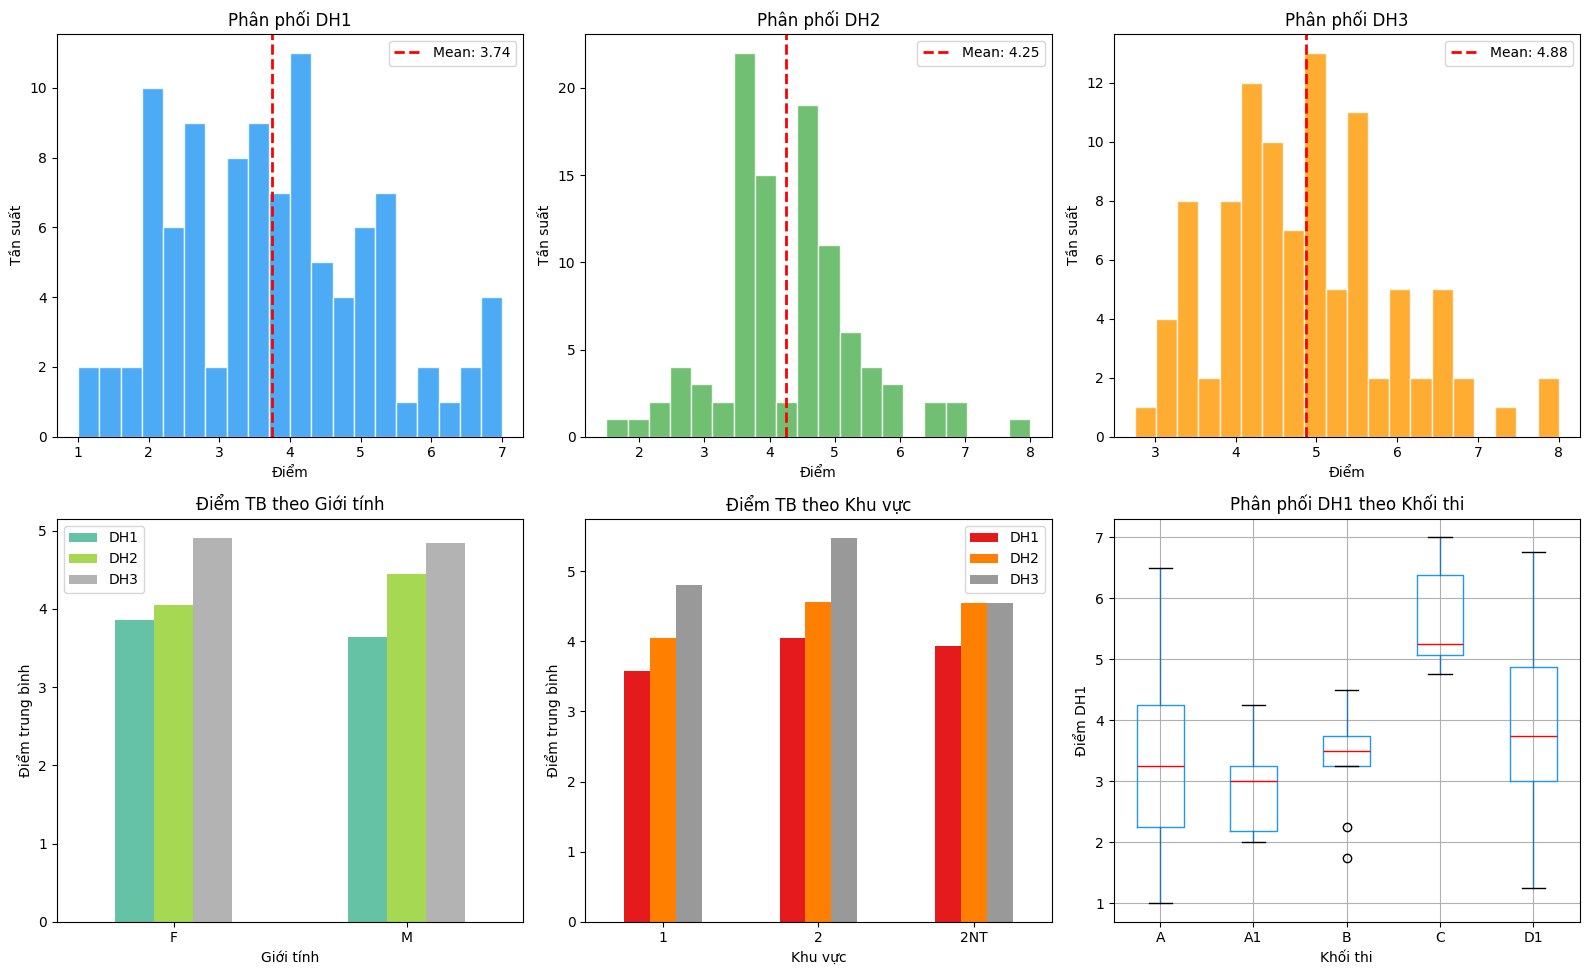

✅ Biểu đồ EDA đã lưu!


In [ ]:
# ============================================================
# Ô 3: Visualize - Phân tích dữ liệu
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("📊 Phân Tích Dữ Liệu Xét Tuyển Đại Học", fontsize=16, fontweight='bold')

# 1. Phân phối điểm DH1, DH2, DH3
for i, col in enumerate(['DH1', 'DH2', 'DH3']):
    axes[0, i].hist(df[col], bins=20, color=['#2196F3','#4CAF50','#FF9800'][i],
                    edgecolor='white', alpha=0.8)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df[col].mean():.2f}')
    axes[0, i].set_title(f'Phân phối {col}', fontsize=12)
    axes[0, i].set_xlabel('Điểm')
    axes[0, i].set_ylabel('Tần suất')
    axes[0, i].legend()

# 4. Điểm TB theo Giới tính
dh_by_gt = df.groupby('GT')[['DH1','DH2','DH3']].mean()
dh_by_gt.plot(kind='bar', ax=axes[1, 0], colormap='Set2', rot=0)
axes[1, 0].set_title('Điểm TB theo Giới tính', fontsize=12)
axes[1, 0].set_xlabel('Giới tính')
axes[1, 0].set_ylabel('Điểm trung bình')
axes[1, 0].legend(['DH1','DH2','DH3'])

# 5. Điểm TB theo Khu vực
dh_by_kv = df.groupby('KV')[['DH1','DH2','DH3']].mean()
dh_by_kv.plot(kind='bar', ax=axes[1, 1], colormap='Set1', rot=0)
axes[1, 1].set_title('Điểm TB theo Khu vực', fontsize=12)
axes[1, 1].set_xlabel('Khu vực')
axes[1, 1].set_ylabel('Điểm trung bình')

# 6. Boxplot DH1 theo Khối thi
df.boxplot(column='DH1', by='KT', ax=axes[1, 2],
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='red'))
axes[1, 2].set_title('Phân phối DH1 theo Khối thi', fontsize=12)
axes[1, 2].set_xlabel('Khối thi')
axes[1, 2].set_ylabel('Điểm DH1')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Biểu đồ EDA đã lưu!")

 Ô 4 — Heatmap tương quan

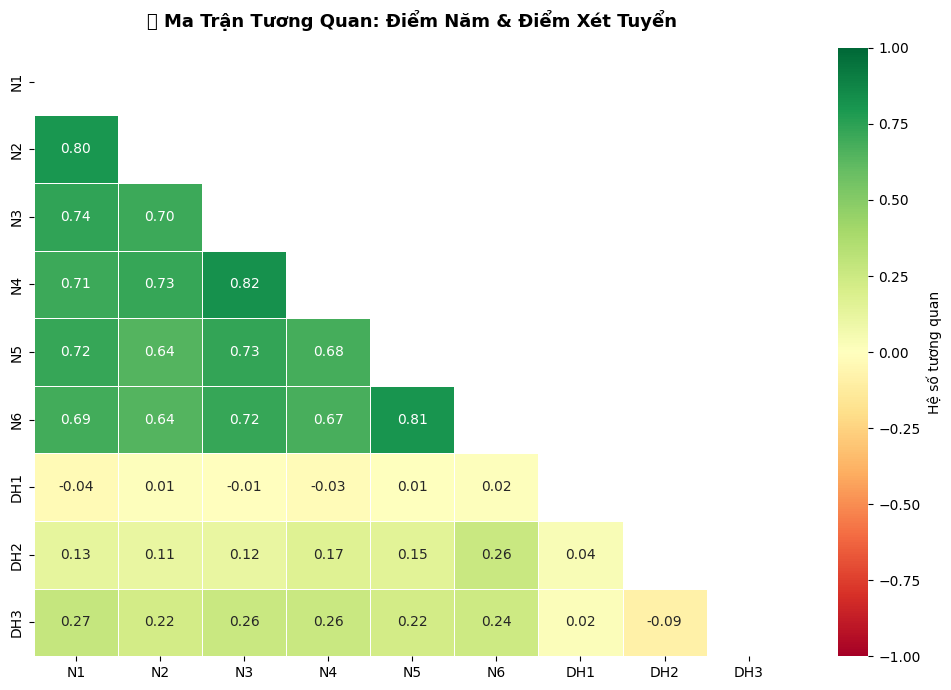


📌 Top 5 feature tương quan với DH1:
DH2    0.035154
DH3    0.018731
N6     0.015352
N2     0.008124
N5     0.006268
Name: DH1, dtype: float64


In [ ]:
# ============================================================
# Ô 4: Correlation Heatmap
# ============================================================
# Lấy điểm trung bình năm + target
n_cols = ['N1','N2','N3','N4','N5','N6']
target_cols = ['DH1','DH2','DH3']
corr_cols = n_cols + target_cols

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # ẩn tam giác trên

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Hệ số tương quan'})
plt.title(' Ma Trận Tương Quan: Điểm Năm & Điểm Xét Tuyển',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n Top 5 feature tương quan với DH1:")
print(corr_matrix['DH1'].sort_values(ascending=False)[1:6])

 Ô 5 — Chuẩn bị features & SPLIT FIRST

In [ ]:
# ============================================================
# Ô 5: Chuẩn bị dữ liệu & SPLIT FIRST (Quy tắc vàng!)
# TUÂN THỦ: Split TRƯỚC khi bất kỳ preprocessing nào
# ============================================================

# --- Chọn Features và Target ---
# Features số: điểm 6 học kỳ của Toán, Lý, Hóa + TB năm
numeric_features = [
    'T1','L1','H1','T2','L2','H2',
    'T3','L3','H3','T4','L4','H4',
    'T5','L5','H5','T6','L6','H6',
    'N1','N2','N3','N4','N5','N6'
]

# Features phân loại: GT (Giới tính), KV (Khu vực), KT (Khối thi)
categorical_features = ['GT', 'KV', 'KT']

# Target: DH1 - Điểm xét tuyển tổ hợp Toán-Lý-Hóa
target = 'DH1'

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

print(f"📐 Shape X: {X.shape}")
print(f"🎯 Target: {target} | Shape y: {y.shape}")
print(f"\n✅ Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"✅ Categorical features ({len(categorical_features)}): {categorical_features}")

# ============================================================
# ⚠️⚠️ SPLIT FIRST - BƯỚC QUAN TRỌNG NHẤT ⚠️⚠️
# Chia TRƯỚC khi fit bất kỳ scaler/encoder nào!
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print(f"\n SAU KHI SPLIT:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\n Test set đã được KHÓA lại — chưa được nhìn!")

📐 Shape X: (100, 27)
🎯 Target: DH1 | Shape y: (100,)

✅ Numeric features (24): ['T1', 'L1', 'H1', 'T2', 'L2', 'H2', 'T3', 'L3', 'H3', 'T4', 'L4', 'H4', 'T5', 'L5', 'H5', 'T6', 'L6', 'H6', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6']
✅ Categorical features (3): ['GT', 'KV', 'KT']

📦 SAU KHI SPLIT:
  X_train: (80, 27) | y_train: (80,)
  X_test:  (20, 27)  | y_test:  (20,)

🔒 Test set đã được KHÓA lại — chưa được nhìn!


Ô 6 — Preprocessing ĐÚNG QUY TRÌNH

In [ ]:
# ============================================================
# Ô 6: Preprocessing - Fit on TRAIN ONLY, Transform cả hai
# TUÂN THỦ: scaler.fit() CHỈ trên X_train
#              scaler.transform() áp lên cả train và test
# ============================================================
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# --- 1. MinMaxScaler cho numeric features ---
# FIT CHỈ TRÊN TRAIN
scaler = MinMaxScaler()
scaler.fit(X_train[numeric_features])           # ← chỉ học từ train!

X_train_num = scaler.transform(X_train[numeric_features])   # áp lên train
X_test_num  = scaler.transform(X_test[numeric_features])    # áp lên test (cùng scaler!)

print("✅ MinMaxScaler: fit on train only")
print(f"   min_ (từ train): {scaler.data_min_[:3]}...")
print(f"   max_ (từ train): {scaler.data_max_[:3]}...")

# --- 2. OneHotEncoder cho categorical features ---
# FIT CHỈ TRÊN TRAIN
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_features])      # ← chỉ học category từ train!

X_train_cat = encoder.transform(X_train[categorical_features])
X_test_cat  = encoder.transform(X_test[categorical_features])

cat_feature_names = encoder.get_feature_names_out(categorical_features)
print(f"\n✅ OneHotEncoder: fit on train only")
print(f"   Categories học được: {[c.tolist() for c in encoder.categories_]}")
print(f"   Các cột mới: {cat_feature_names.tolist()}")

# --- 3. Ghép lại ---
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num,  X_test_cat])

print(f"\n📐 Final shape:")
print(f"  X_train_final: {X_train_final.shape}")
print(f"  X_test_final:  {X_test_final.shape}")

# Scale target y về [0,1] để ổn định training
y_scaler = MinMaxScaler()
y_scaler.fit(y_train.values.reshape(-1, 1))   # ← fit chỉ trên y_train!

y_train_scaled = y_scaler.transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print(f"\n Target y_train scaled: min={y_train_scaled.min():.3f}, max={y_train_scaled.max():.3f}")

✅ MinMaxScaler: fit on train only
   min_ (từ train): [2.4 1.8 3. ]...
   max_ (từ train): [9.3 8.  9.1]...

✅ OneHotEncoder: fit on train only
   Categories học được: [['F', 'M'], ['1', '2', '2NT'], ['A', 'A1', 'B', 'C', 'D1']]
   Các cột mới: ['GT_F', 'GT_M', 'KV_1', 'KV_2', 'KV_2NT', 'KT_A', 'KT_A1', 'KT_B', 'KT_C', 'KT_D1']

📐 Final shape:
  X_train_final: (80, 34)
  X_test_final:  (20, 34)

✅ Target y_train scaled: min=0.000, max=1.000


Ô 7 — Linear Regression với TensorFlow / Keras

In [ ]:
# ============================================================
# Ô 7: Mô hình Linear Regression - TensorFlow
# ============================================================
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
print(f"TensorFlow version: {tf.__version__}")

# Số lượng input features
n_features = X_train_final.shape[1]
print(f"Số features đầu vào: {n_features}")

# Xây dựng model Linear Regression thuần túy (1 Dense layer, không activation)
model_tf = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(1, activation='linear',
                       kernel_initializer='glorot_uniform',
                       bias_initializer='zeros',
                       name='linear_output')
], name='LinearRegression_TF')

# Compile
model_tf.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='mse',
    metrics=['mae']
)

model_tf.summary()

TensorFlow version: 2.20.0
Số features đầu vào: 34


Model: "LinearRegression_TF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ linear_output (Dense)           │ (None, 1)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

Ô 8 — Huấn luyện TensorFlow

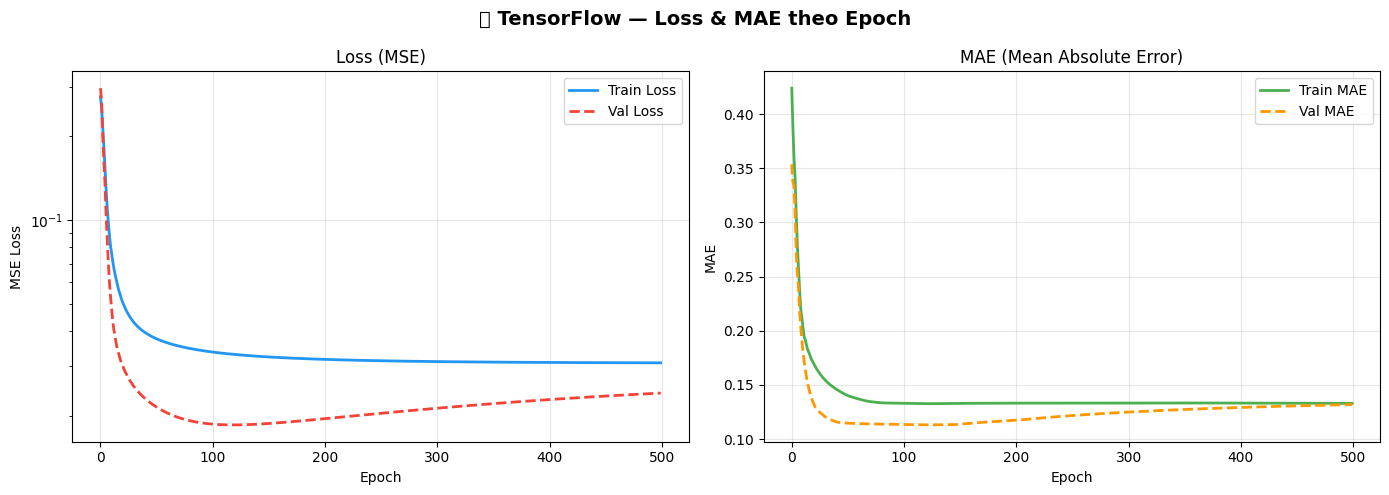


🏆 Best epoch: 119
   Train Loss: 0.033146
   Val Loss:   0.018522


In [ ]:
# ============================================================
# Ô 8: Train TensorFlow model
# ============================================================
EPOCHS = 500
BATCH_SIZE = 16

history_tf = model_tf.fit(
    X_train_final, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 20% từ train làm validation (KHÔNG DÙNG TEST!)
    verbose=0               # ẩn log từng epoch
)

# Plot Loss & MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📉 TensorFlow — Loss & MAE theo Epoch', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history_tf.history['loss'], label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(history_tf.history['val_loss'], label='Val Loss',
             color='#F44336', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

# MAE
axes[1].plot(history_tf.history['mae'], label='Train MAE', color='#4CAF50', linewidth=2)
axes[1].plot(history_tf.history['val_mae'], label='Val MAE',
             color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE (Mean Absolute Error)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tf_loss_mae.png', dpi=120, bbox_inches='tight')
plt.show()

# Lấy best epoch
best_epoch = np.argmin(history_tf.history['val_loss'])
print(f"\n Best epoch: {best_epoch+1}")
print(f"   Train Loss: {history_tf.history['loss'][best_epoch]:.6f}")
print(f"   Val Loss:   {history_tf.history['val_loss'][best_epoch]:.6f}")

Ô 9 — Đánh giá TensorFlow (TEST CHỈ 1 LẦN!)

📊 KẾT QUẢ ĐÁNH GIÁ — TENSORFLOW
  MSE  (Mean Squared Error):  1.8040
  RMSE (Root MSE):            1.3431
  MAE  (Mean Absolute Error): 1.1019
  R²   (Coefficient of Det.): -0.0672


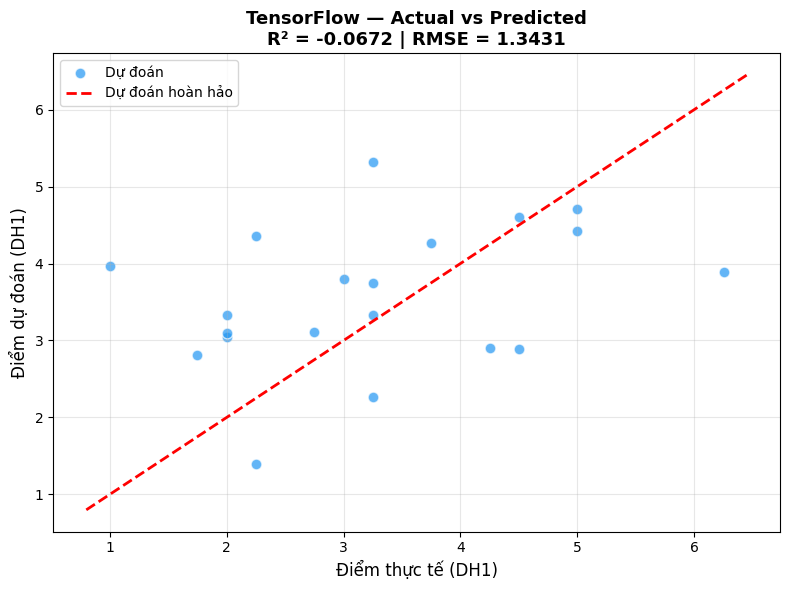

In [ ]:
# ============================================================
# Ô 9: Đánh giá TF — TEST CHỈ ĐƯỢC DÙNG ĐÚng 1 LẦN!
# ⚠️ TUÂN THỦ: Không tune sau khi đã nhìn test!
# ============================================================

# Dự đoán (đầu ra scaled)
y_pred_scaled_tf = model_tf.predict(X_test_final, verbose=0).flatten()

# Chuyển về thang điểm gốc
y_pred_tf = y_scaler.inverse_transform(y_pred_scaled_tf.reshape(-1, 1)).flatten()
y_test_orig = y_test.values

# Tính metrics
mse_tf  = mean_squared_error(y_test_orig, y_pred_tf)
rmse_tf = np.sqrt(mse_tf)
mae_tf  = mean_absolute_error(y_test_orig, y_pred_tf)
r2_tf   = r2_score(y_test_orig, y_pred_tf)

print("=" * 45)
print(" KẾT QUẢ ĐÁNH GIÁ — TENSORFLOW")
print("=" * 45)
print(f"  MSE  (Mean Squared Error):  {mse_tf:.4f}")
print(f"  RMSE (Root MSE):            {rmse_tf:.4f}")
print(f"  MAE  (Mean Absolute Error): {mae_tf:.4f}")
print(f"  R²   (Coefficient of Det.): {r2_tf:.4f}")
print("=" * 45)

# Biểu đồ Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_tf, alpha=0.7, color='#2196F3',
            edgecolors='white', s=60, label='Dự đoán')
min_val = min(y_test_orig.min(), y_pred_tf.min()) - 0.2
max_val = max(y_test_orig.max(), y_pred_tf.max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], 'r--',
         linewidth=2, label='Dự đoán hoàn hảo')
plt.xlabel('Điểm thực tế (DH1)', fontsize=12)
plt.ylabel('Điểm dự đoán (DH1)', fontsize=12)
plt.title(f'TensorFlow — Actual vs Predicted\nR² = {r2_tf:.4f} | RMSE = {rmse_tf:.4f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tf_actual_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()

Ô 10 — Linear Regression với PyTorch

In [ ]:
# ============================================================
# Ô 10: Mô hình Linear Regression - PyTorch
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

# Chuyển sang Tensor
X_train_t = torch.FloatTensor(X_train_final)
X_test_t  = torch.FloatTensor(X_test_final)
y_train_t = torch.FloatTensor(y_train_scaled).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_test_scaled).unsqueeze(1)

# Dataset & DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Định nghĩa model Linear Regression thuần túy
class LinearRegressionPT(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

model_pt = LinearRegressionPT(n_features=X_train_final.shape[1])
print(model_pt)
print(f"\nSố tham số: {sum(p.numel() for p in model_pt.parameters()):,}")

# Loss & Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_pt.parameters(), lr=0.01, momentum=0.9)

PyTorch version: 2.10.0+cpu
LinearRegressionPT(
  (linear): Linear(in_features=34, out_features=1, bias=True)
)

Số tham số: 35


Ô 11 — Huấn luyện PyTorch

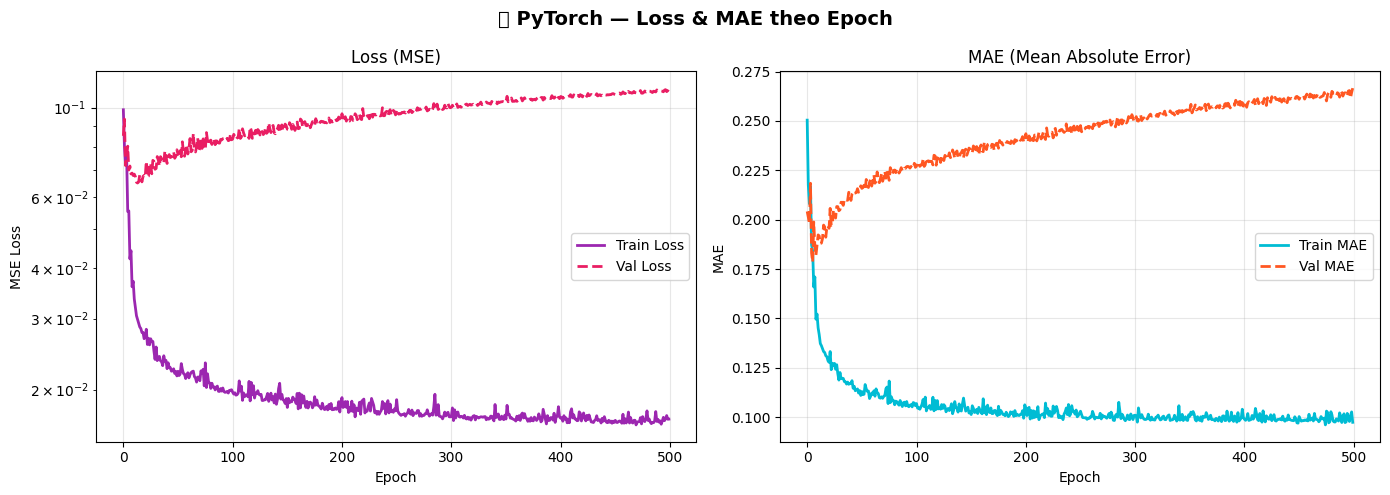


🏆 Best epoch: 14
   Train Loss: 0.029878
   Val Loss:   0.065036


In [ ]:
# ============================================================
# Ô 11: Train PyTorch model
# ============================================================
EPOCHS_PT = 500

# Tách validation từ TRAIN (không dùng test!)
val_size = int(0.2 * len(X_train_t))
X_val_t   = X_train_t[:val_size]
y_val_t   = y_train_t[:val_size]
X_tr_t    = X_train_t[val_size:]
y_tr_t    = y_train_t[val_size:]

tr_dataset  = TensorDataset(X_tr_t, y_tr_t)
tr_loader   = DataLoader(tr_dataset, batch_size=16, shuffle=True)

train_losses_pt = []
val_losses_pt   = []
train_maes_pt   = []
val_maes_pt     = []

for epoch in range(EPOCHS_PT):
    # --- Training ---
    model_pt.train()
    batch_losses, batch_maes = [], []

    for X_batch, y_batch in tr_loader:
        optimizer.zero_grad()
        y_hat = model_pt(X_batch)
        loss  = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        batch_maes.append(torch.mean(torch.abs(y_hat - y_batch)).item())

    train_losses_pt.append(np.mean(batch_losses))
    train_maes_pt.append(np.mean(batch_maes))

    # --- Validation ---
    model_pt.eval()
    with torch.no_grad():
        y_val_pred = model_pt(X_val_t)
        val_loss   = criterion(y_val_pred, y_val_t).item()
        val_mae    = torch.mean(torch.abs(y_val_pred - y_val_t)).item()

    val_losses_pt.append(val_loss)
    val_maes_pt.append(val_mae)

# Plot Loss & MAE - PyTorch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' PyTorch — Loss & MAE theo Epoch', fontsize=14, fontweight='bold')

axes[0].plot(train_losses_pt, label='Train Loss', color='#9C27B0', linewidth=2)
axes[0].plot(val_losses_pt,   label='Val Loss',   color='#E91E63', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

axes[1].plot(train_maes_pt, label='Train MAE', color='#00BCD4', linewidth=2)
axes[1].plot(val_maes_pt,   label='Val MAE',   color='#FF5722', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE (Mean Absolute Error)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pt_loss_mae.png', dpi=120, bbox_inches='tight')
plt.show()

best_epoch_pt = np.argmin(val_losses_pt)
print(f"\n Best epoch: {best_epoch_pt+1}")
print(f"   Train Loss: {train_losses_pt[best_epoch_pt]:.6f}")
print(f"   Val Loss:   {val_losses_pt[best_epoch_pt]:.6f}")

Ô 12 — Đánh giá PyTorch

📊 KẾT QUẢ ĐÁNH GIÁ — PYTORCH
  MSE  (Mean Squared Error):  2.8574
  RMSE (Root MSE):            1.6904
  MAE  (Mean Absolute Error): 1.3503
  R²   (Coefficient of Det.): -0.6903


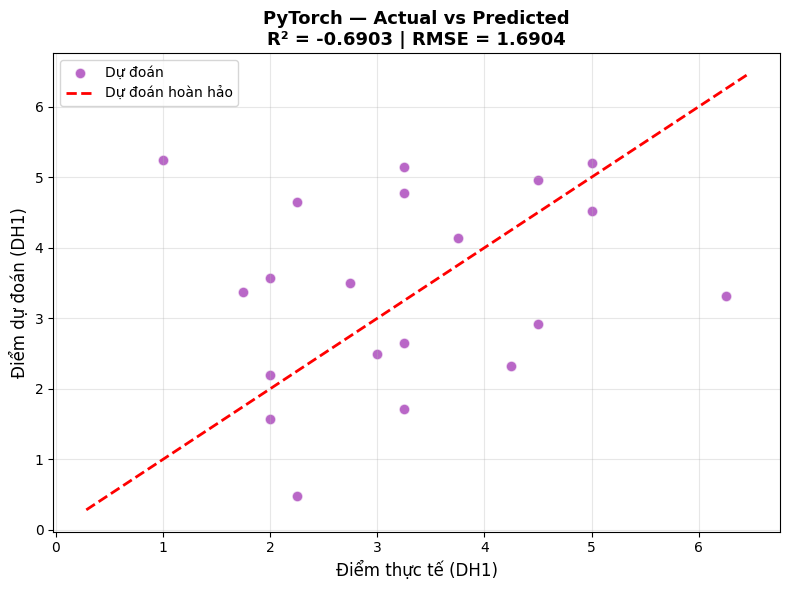

In [ ]:
# ============================================================
# Ô 12: Đánh giá PyTorch — TEST CHỈ DÙNG 1 LẦN!
# ============================================================
model_pt.eval()
with torch.no_grad():
    y_pred_scaled_pt = model_pt(X_test_t).numpy().flatten()

# Inverse transform về thang gốc
y_pred_pt   = y_scaler.inverse_transform(y_pred_scaled_pt.reshape(-1,1)).flatten()
y_test_orig = y_test.values

mse_pt  = mean_squared_error(y_test_orig, y_pred_pt)
rmse_pt = np.sqrt(mse_pt)
mae_pt  = mean_absolute_error(y_test_orig, y_pred_pt)
r2_pt   = r2_score(y_test_orig, y_pred_pt)

print("=" * 45)
print(" KẾT QUẢ ĐÁNH GIÁ — PYTORCH")
print("=" * 45)
print(f"  MSE  (Mean Squared Error):  {mse_pt:.4f}")
print(f"  RMSE (Root MSE):            {rmse_pt:.4f}")
print(f"  MAE  (Mean Absolute Error): {mae_pt:.4f}")
print(f"  R²   (Coefficient of Det.): {r2_pt:.4f}")
print("=" * 45)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_pt, alpha=0.7, color='#9C27B0',
            edgecolors='white', s=60, label='Dự đoán')
min_val = min(y_test_orig.min(), y_pred_pt.min()) - 0.2
max_val = max(y_test_orig.max(), y_pred_pt.max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Dự đoán hoàn hảo')
plt.xlabel('Điểm thực tế (DH1)', fontsize=12)
plt.ylabel('Điểm dự đoán (DH1)', fontsize=12)
plt.title(f'PyTorch — Actual vs Predicted\nR² = {r2_pt:.4f} | RMSE = {rmse_pt:.4f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pt_actual_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()

Ô 13 — So sánh TensorFlow vs PyTorch


🏆 BẢNG SO SÁNH KẾT QUẢ


,Framework,MSE,RMSE,MAE,R²
0,TensorFlow / Keras,1.8040,1.3431,1.1019,-0.0672
1,PyTorch,2.8574,1.6904,1.3503,-0.6903


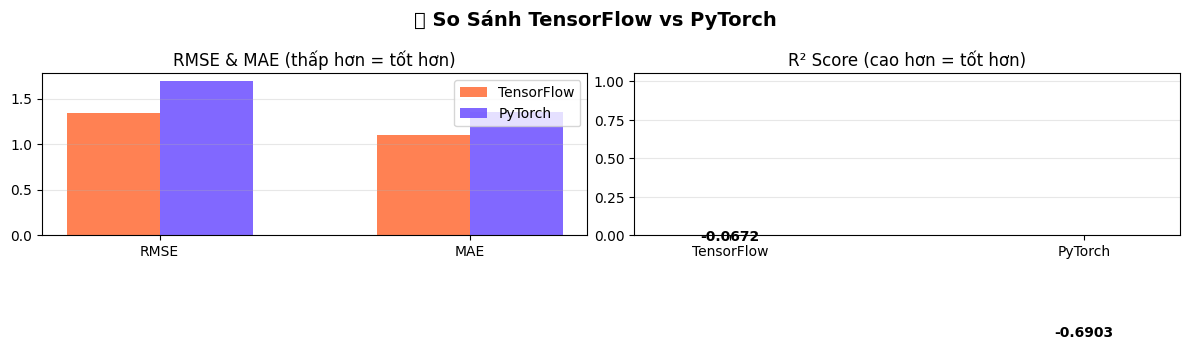

In [ ]:
# ============================================================
# Ô 13: So sánh kết quả 2 framework
# ============================================================
comparison = {
    'Framework': ['TensorFlow / Keras', 'PyTorch'],
    'MSE':  [round(mse_tf, 4),  round(mse_pt, 4)],
    'RMSE': [round(rmse_tf, 4), round(rmse_pt, 4)],
    'MAE':  [round(mae_tf, 4),  round(mae_pt, 4)],
    'R²':   [round(r2_tf, 4),   round(r2_pt, 4)],
}

df_compare = pd.DataFrame(comparison)
print("\n" + "=" * 55)
print(" BẢNG SO SÁNH KẾT QUẢ")
print("=" * 55)
display(df_compare)

# Biểu đồ so sánh metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(' So Sánh TensorFlow vs PyTorch', fontsize=14, fontweight='bold')

metrics_compare = ['RMSE', 'MAE']
values_tf = [rmse_tf, mae_tf]
values_pt = [rmse_pt, mae_pt]
x = np.arange(len(metrics_compare))
width = 0.3

axes[0].bar(x - width/2, values_tf, width, label='TensorFlow', color='#FF6B35', alpha=0.85)
axes[0].bar(x + width/2, values_pt, width, label='PyTorch',    color='#6B4EFF', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_compare)
axes[0].set_title('RMSE & MAE (thấp hơn = tốt hơn)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² comparison
r2_vals = [r2_tf, r2_pt]
colors  = ['#FF6B35', '#6B4EFF']
bars = axes[1].bar(['TensorFlow', 'PyTorch'], r2_vals, color=colors, alpha=0.85, width=0.4)
axes[1].set_title('R² Score (cao hơn = tốt hơn)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Ô 14 — Kiểm tra tuân thủ quy tắc

In [ ]:
# ============================================================
# Ô 14: Checklist xác nhận tuân thủ quy tắc từ tài liệu
# ============================================================
checklist = [
    ("✅", "Split data FIRST trước bất kỳ preprocessing nào"),
    ("✅", "MinMaxScaler.fit() CHỈ trên X_train"),
    ("✅", "OneHotEncoder.fit() CHỈ trên X_train"),
    ("✅", "transform() áp dụng đồng đều cho cả train và test"),
    ("✅", "Test set chỉ dùng 1 lần duy nhất (đánh giá cuối)"),
    ("✅", "Validation tách từ TRAIN (không dùng test để tune)"),
    ("✅", "handle_unknown='ignore' cho OneHotEncoder"),
    ("✅", "y_scaler.fit() CHỈ trên y_train"),
    ("✅", "Không fit scaler riêng trên test"),
    ("✅", "Không dùng pd.get_dummies() độc lập cho train/test"),
]

print("=" * 60)
print("CHECKLIST TUÂN THỦ QUY TẮC PREPROCESSING")
print("=" * 60)
for status, rule in checklist:
    print(f"  {status}  {rule}")
print("=" * 60)
print(f"\n TẤT CẢ {len(checklist)}/{len(checklist)} QUY TẮC ĐÃ ĐƯỢC TUÂN THỦ!")
print("\n Quy tắc vàng: Split → Fit(train) → Transform(all) → Test ONCE")

📋 CHECKLIST TUÂN THỦ QUY TẮC PREPROCESSING
  ✅  Split data FIRST trước bất kỳ preprocessing nào
  ✅  MinMaxScaler.fit() CHỈ trên X_train
  ✅  OneHotEncoder.fit() CHỈ trên X_train
  ✅  transform() áp dụng đồng đều cho cả train và test
  ✅  Test set chỉ dùng 1 lần duy nhất (đánh giá cuối)
  ✅  Validation tách từ TRAIN (không dùng test để tune)
  ✅  handle_unknown='ignore' cho OneHotEncoder
  ✅  y_scaler.fit() CHỈ trên y_train
  ✅  Không fit scaler riêng trên test
  ✅  Không dùng pd.get_dummies() độc lập cho train/test

✅ TẤT CẢ 10/10 QUY TẮC ĐÃ ĐƯỢC TUÂN THỦ!

🎯 Quy tắc vàng: Split → Fit(train) → Transform(all) → Test ONCE
